# 土木のためのPython入門⑤ NumPy入門編

<div class="alert alert-info">
<strong>info</strong><br>
この記事では、土木工学を学ぶ学生を対象に、Pythonの数値計算ライブラリ <strong>NumPy</strong> の基本を解説します。<br><br>
この記事では、
- NumPyと<code>ndarray</code>
- 配列の基本操作
- ブロードキャスト
- ベクトル・行列
- 連立方程式
- NumPyとpandas・Matplotlibの関係
- 生成AIを使ったNumPy学習
について扱います。
</div>

<div class="alert alert-warning">
<strong>warn</strong><br>
<strong>この記事を読む前に</strong><br>
- 本記事は筆者個人の学習記録であり、所属する大学や特定の団体の公式見解ではありません。<br>
- 本記事の内容には十分注意を払っていますが、正確性や完全性を保証するものではありません。<br>
- 本記事を参考にする場合は、必ずご自身でも最新の公式情報等をご確認ください。<br>
- 本記事の利用によって生じたいかなる損害についても、筆者は責任を負いかねます。
</div>

今回のサンプルコードはGitHubにも公開しています。

また、Google Colabからコードを実行することもできます。

---

## 0. はじめに

前回は、Pythonでグラフを作成するための **Matplotlib** について学びました。

Matplotlibを使うと、河川水位や雨量、交通量などのデータをグラフとして可視化できます。

一方、土木工学ではグラフを作るだけでなく、

- 行列計算
- 連立方程式
- 座標計算
- 数値微分・数値積分
- 構造解析
- 水理計算
- シミュレーション

など、大量の数値を扱うこともあります。

そこで登場するのが **NumPy** です。

NumPyは、Pythonで数値計算を行うための代表的なライブラリです。

今回は細かい関数を暗記するのではなく、

> **NumPyを使うと何ができるのか**

を理解することを目標にします。

---

## 1. NumPyとは

NumPyは、Pythonで**配列を使った数値計算**を行うためのライブラリです。

一般的には、`import numpy as np` として利用します。

NumPyの中心となるのが `ndarray` という多次元配列です。

In [2]:
import numpy as np

# 河川水位のデータを配列として定義
water_level = np.array([1.2, 1.5, 1.4, 2.1, 2.8])

print(type(water_level))

<class 'numpy.ndarray'>


このように、`np.array()` で作った配列は `ndarray` です。

---

## 2. NumPyは土木で何に使う？

NumPyは土木専用のライブラリではありませんが、土木工学で扱う数値データと相性がよいライブラリです。

例えば、

| 分野 | 利用例 |
| ------ | ------------------- |
| 構造 | 荷重・変位データ、剛性行列、連立方程式 |
| 水理 | 水位・流量、数値積分、数値微分 |
| 地盤 | 地盤データ、パラメータ計算 |
| 交通 | 交通量、時系列データ、シミュレーション |
| 測量・GIS | 座標、距離、標高データ |

などに利用できます。

つまりNumPyは、

> **土木工学で扱う数値を計算するための基盤**

として利用できます。

---

## 3. PythonのリストとNumPy配列

Pythonにはもともとリストがあります。

In [3]:
a = [1, 2, 3]
b = [4, 5, 6]

print(a + b)

[1, 2, 3, 4, 5, 6]


これは数値の足し算ではなく、リストの連結です。

一方、NumPyでは、

In [4]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print(a + b)

[5 7 9]


となります。

NumPyでは、配列の要素に対する計算をまとめて行えます。

例えば、

In [5]:
data = np.array([1, 2, 3, 4, 5])

print(data + 10)
print(data * 2)
print(data / 2)

[11 12 13 14 15]
[ 2  4  6  8 10]
[0.5 1.  1.5 2.  2.5]


このような**配列演算**がNumPyの基本です。

---

## 4. 土木データを計算する

河川水位を例にしてみます。

In [6]:
water_level = np.array([
    1.2,
    1.5,
    1.4,
    2.1,
    2.8
])

# すべての水位に0.3 mを加える場合
corrected_level = water_level + 0.3

print(corrected_level)

[1.5 1.8 1.7 2.4 3.1]


NumPyでは、このように配列全体へ一度に計算を適用できます。

最大値・最小値・平均値も簡単に求められます。

In [7]:
print("最大水位:", np.max(water_level))
print("最小水位:", np.min(water_level))
print("平均水位:", np.mean(water_level))

最大水位: 2.8
最小水位: 1.2
平均水位: 1.8


観測データの処理では、このような計算が頻繁に登場します。

---

## 5. ブロードキャスト

先ほど、`water_level + 0.3` という計算を行いました。

配列と1つの数値を計算できたのは、NumPyの **ブロードキャスト（broadcasting）** という仕組みによるものです。

例えば、

In [8]:
data = np.array([1, 2, 3])

print(data + 10)

[11 12 13]


イメージとしては、

```text
[1, 2, 3] + [10, 10, 10]
```

のように考えると分かりやすいでしょう。

ただし、どのような形の配列でも計算できるわけではありません。

NumPyでは、

> **配列の値だけでなく、配列の形（shape）も意識する**

ことが重要です。

---

## 6. 配列の形を確認する

NumPyでは、配列の構造を確認するために、

* `shape`
* `ndim`
* `size`
* `dtype`

などを利用します。

In [9]:
data = np.array([1, 2, 3, 4, 5])

print("shape:", data.shape)
print("ndim :", data.ndim)
print("size :", data.size)
print("dtype:", data.dtype)

shape: (5,)
ndim : 1
size : 5
dtype: int64


それぞれ、

| 属性 | 意味 |
| ------- | ------- |
| `shape` | 各次元の大きさ |
| `ndim` | 次元数 |
| `size` | 要素数 |
| `dtype` | データ型 |

を表します。

`dtype` は環境や作成方法によって異なる場合があります。

---

## 7. 2次元配列と行列

NumPyでは2次元以上の配列も扱えます。

In [10]:
data = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

print(data)
print("shape:", data.shape)

[[1 2 3]
 [4 5 6]
 [7 8 9]]
shape: (3, 3)


`(3, 3)` は3行3列を意味します。

このような2次元配列は、数学で扱う行列を表現するためにも利用できます。

例えば、

$$
A=
\begin{pmatrix}
1 & 2\\
3 & 4
\end{pmatrix}
$$

は、次のように定義できます。

In [11]:
A = np.array([
    [1, 2],
    [3, 4]
])

print(A)

[[1 2]
 [3 4]]


### `np.matrix` は使わない

古いPython・NumPyの資料では `np.matrix` が使われていることがあります。

しかし、現在のNumPyでは新しいコードに `np.matrix` を使用することは推奨されていません。

このシリーズでは、`np.array(...)` による2次元 `ndarray` を基本とします。

---

## 8. `*` と `@` の違い

行列計算では、`*` と `@` の違いに注意しましょう。

In [12]:
A = np.array([
    [1, 2],
    [3, 4]
])

B = np.array([
    [5, 6],
    [7, 8]
])

# 要素ごとの掛け算
print("--- A * B (要素ごとの積) ---")
print(A * B)

# 行列積
print("\n--- A @ B (行列積) ---")
print(A @ B)

--- A * B (要素ごとの積) ---
[[ 5 12]
 [21 32]]

--- A @ B (行列積) ---
[[19 22]
 [43 50]]


つまり、

- `A * B` → 要素ごとの積
- `A @ B` → 行列積

です。

行列計算では、この違いを必ず覚えておきましょう。

---

## 9. 連立方程式を解く

土木工学では、行列を使った連立方程式が頻繁に登場します。

例えば、

$$
\begin{aligned}
2x+y&=5\\
x+3y&=6
\end{aligned}
$$

を考えます。

行列形式では、

$$\begin{pmatrix}2&1\\1&3\end{pmatrix}\begin{pmatrix}x\\y\end{pmatrix}=\begin{pmatrix}5\\6\end{pmatrix}$$

となります。

In [13]:
A = np.array([
    [2, 1],
    [1, 3]
])

b = np.array([5, 6])

x = np.linalg.solve(A, b)

print("解 (x, y):", x)

解 (x, y): [1.8 1.4]


したがって、

$$
x=1.8,\qquad y=1.4
$$

です。

### `np.linalg.solve()` の注意点

`np.linalg.solve()` は、どんな連立方程式でも解けるわけではありません。

基本的には、係数行列 `A` が**正方行列かつフルランク**である必要があります。

そのため、

> 「連立方程式だからとりあえず `np.linalg.solve()`」

ではなく、まず数学的にどのような問題なのかを確認することが重要です。

例えば最小二乗法を行う場合には、`np.linalg.lstsq()` など別の方法を検討します。

---

## 10. NumPyのビューとコピー

NumPyでは、配列の一部を取り出したときの扱いにも注意が必要です。

In [14]:
data = np.array([10, 20, 30, 40, 50])

# スライスにより部分配列を取得（ビュー）
part = data[1:4]
print("part:", part)

# ビュー要素を変更すると...
part[0] = 999

# 元の配列 data も変更される！
print("data:", data)

part: [20 30 40]
data: [ 10 999  30  40  50]


これは、基本的なスライスによって得られた `part` が元の配列の**ビュー**になっているためです。

元の配列とは独立したデータとして扱いたい場合は、`.copy()` を使います。

In [15]:
data = np.array([10, 20, 30, 40, 50])

# コピーを取得
part = data[1:4].copy()
part[0] = 999

print("part:", part)
print("data:", data)  # 元のデータは影響を受けない

part: [999  30  40]
data: [10 20 30 40 50]


NumPyを使うときは、

> **この配列は元のデータを共有しているのか？**

という点を意識しておくと、意図しないデータ変更を防げます。

---

## 11. NumPyとpandas・Matplotlib

ここまで学んできたpandasやMatplotlibとNumPyは、組み合わせて使うことができます。

大まかには、

| ライブラリ | 主な役割 |
| ---------- | ------------ |
| NumPy | 数値配列・数値計算 |
| pandas | 表形式データの整理・分析 |
| Matplotlib | データの可視化 |

という関係です。

例えば、

```text
CSV
 ↓
pandasで読み込む
 ↓
NumPyで計算
 ↓
Matplotlibで可視化
```

という流れでデータを処理できます。

---

## 12. NumPyとMatplotlibを組み合わせる

例えば、NumPyで $y=x^2$ を計算してMatplotlibで表示してみます。

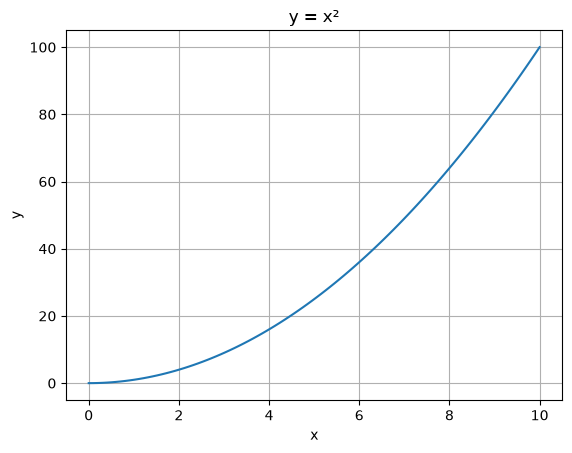

In [17]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 10, 100)
y = x ** 2

plt.plot(x, y)

plt.xlabel("x")
plt.ylabel("y")
plt.title("y = x²")

plt.grid()
plt.show()

ここでは、`np.linspace(0, 10, 100)` によって、0から10までの範囲を100個の点に分けています。

その `x` を使って、$y=x^2$ を計算しています。

このように、

```text
NumPy
 ↓
計算
 ↓
Matplotlib
 ↓
可視化
```

という組み合わせは、Pythonによるデータ分析でよく使われます。

---

## 13. NumPyの関数は全部覚える必要がある？

NumPyには非常に多くの関数があります。

例えば、

- `np.array()`
- `np.zeros()`
- `np.ones()`
- `np.arange()`
- `np.linspace()`
- `np.mean()`
- `np.max()`
- `np.min()`
- `np.sum()`
- `np.sqrt()`
- `np.exp()`
- `np.log()`
- `np.reshape()`
- `np.concatenate()`
- `np.linalg.solve()`

などです。

しかし、これらをすべて暗記する必要はありません。

重要なのは、

```text
何を計算したいか
        ↓
どのような数学的処理か
        ↓
どの機能を使えばよいか調べる
        ↓
コードを書く
        ↓
結果を確認する
```

という流れを身につけることです。

例えば、

> 「連立一次方程式を解きたい」

という問題に対して、`np.linalg.solve()` という関数があることを知っていれば、必要になったときに使い方を調べられます。

公式ドキュメントや検索、生成AIを利用して調べることも有効です。

---

## 14. 生成AIとNumPy

2026年現在、生成AIはPython学習やコード作成の補助として利用できます。

例えば、

```text
NumPyを使って、河川水位の配列から
最大値、最小値、平均値を計算するコードを書いてください。
```

と指示すれば、コードの例を得られます。

ただし、

> **AIがコードを書けることと、そのコードが正しいことは別問題です。**

特に土木工学では、

- 配列の形
- 数式
- 単位
- 前提条件
- 計算方法
- 結果の妥当性

を確認する必要があります。

例えば、コードが正常に実行できても、

```text
m と mm
m³/s と L/s
度 と ラジアン
```

などを間違えていれば、結果は意味を持ちません。

そのため、

```text
AIにコードを書かせる
        ↓
コードを読む
        ↓
実行する
        ↓
数式・単位・shapeを確認する
        ↓
結果の妥当性を確認する
```

という使い方を意識しましょう。

土木工学では、

> **「コードが動く」ことより「計算結果が工学的に正しい」ことが重要**

です。

---

## 15. 今回学んだこと

今回はNumPyの基本を学びました。

重要なポイントは次の通りです。

- NumPyはPythonの代表的な数値計算ライブラリ
- `ndarray` がNumPyの基本的な配列
- 配列に対してまとめて計算できる
- ブロードキャストによって配列と単一の値などを計算できる
- `shape` で配列の形を確認できる
- `ndim` で次元数を確認できる
- 2次元 `ndarray` で行列を表現できる
- `*` は要素ごとの積、`@` は行列積
- `np.linalg.solve()` で連立一次方程式を解ける
- NumPyのスライスではビューが返る場合がある
- 必要に応じて `.copy()` を使う
- pandasやMatplotlibと組み合わせて利用できる
- NumPyの関数をすべて暗記する必要はない
- 生成AIをコード作成の補助として利用できる
- AIが生成したコードや結果を検証することが重要

---

## 16. 次回以降について

ここまでで、

```text
Python
 ↓
pandas
 ↓
Matplotlib
 ↓
NumPy
```

というPythonによるデータ処理・可視化・数値計算の基本的な道具を学びました。

これらを組み合わせると、

```text
データを読み込む
 ↓
pandasで整理する
 ↓
NumPyで計算する
 ↓
Matplotlibで可視化する
 ↓
結果を考察する
```

という流れでデータを扱えるようになります。

例えば河川データなら、

```text
雨量データ
 ↓
pandasで読み込む
 ↓
NumPyで計算
 ↓
Matplotlibで可視化
 ↓
雨量と水位の関係を考察
```

という処理ができます。

さらにPythonを土木工学へ応用すると、

- SciPy
- 統計解析
- 回帰分析
- GIS
- 機械学習
- 深層学習
- 数値解析
- 有限要素法
- PINN（Physics-Informed Neural Networks）

などにもつながっていきます。

Pythonそのものを目的にするのではなく、

> **土木工学の問題を理解し、Pythonを道具として使って解決する**

ことを意識して学んでいきましょう。

---

## まとめ

NumPyは、Pythonで数値計算や配列・行列を扱うための基本的なライブラリです。

最初からすべての関数を暗記する必要はありません。

まずは、

```text
ndarray
shape
broadcasting
ベクトル・行列
@
np.linalg.solve()
```

といった基本的な考え方を理解しましょう。

書籍や公式ドキュメント、検索、生成AIなどから調べて使えるようになることが重要です。

ただし、生成AIを利用する場合も、コードをそのまま信じるのではなく、

- 何を計算しているのか
- 数学的に正しいのか
- 配列の形は適切か
- 単位は正しいか
- 結果は工学的に妥当か

を確認する習慣を身につけましょう。

**Pythonを使って、土木工学の問題を自分で考え、計算し、結果を検証できるようになること。**

これを目標にしていきましょう。